#### This notebook decides the best model out of all the built models, loads it here, and draws insights from the model.

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

In [2]:
import src
print("src is now discoverable")

src is now discoverable


##### Pasting the metrics of all the trained models here and comparing them on the basis of precision, recall, and f1-score to choose the best model

In [3]:
import pandas as pd

In [4]:
log_reg_metrics = {
    "model": "Logistic Regression",
    "accuracy": 0.9788789982759429,
    "roc_auc": 0.9929508592095224,

    "precision_0": 1.00,
    "recall_0": 0.98,
    "f1_0": 0.99,

    "precision_1": 0.57,
    "recall_1": 0.92,
    "f1_1": 0.71,

    "TN": 183072,
    "FP": 3641,
    "FN": 414,
    "TP": 4862
}

rf_metrics = {
    "model": "Random Forest",
    "accuracy": 0.9881816145716682,
    "roc_auc": 0.9962370893071175,

    # Class 0 metrics
    "precision_0": 1.00,
    "recall_0": 0.99,
    "f1_0": 0.99,

    # Class 1 metrics
    "precision_1": 0.73,
    "recall_1": 0.90,
    "f1_1": 0.81,

    # Confusion matrix values
    "TN": 184989,
    "FP": 1724,
    "FN": 545,
    "TP": 4731
}

lgbm_metrics = {
    "model": "LightGBM (thr=0.9)",
    "accuracy": 0.9893275135554641,
    "roc_auc": 0.997054205648059,

    "precision_0": 1.00,
    "recall_0": 0.99,
    "f1_0": 0.99,

    "precision_1": 0.75,
    "recall_1": 0.91,
    "f1_1": 0.82,

    "TN": 185143,
    "FP": 1570,
    "FN": 479,
    "TP": 4797
}

xgb_08_metrics = {
    "model": "XGBoost (thr=0.8)",
    "accuracy": 0.9887389381683326,
    "roc_auc": 0.9972843807664706,

    "precision_0": 1.00,
    "recall_0": 0.99,
    "f1_0": 0.99,

    "precision_1": 0.73,
    "recall_1": 0.93,
    "f1_1": 0.82,

    "TN": 184888,
    "FP": 1825,
    "FN": 347,
    "TP": 4929
}

xgb_09_metrics = {
    "model": "XGBoost (thr=0.9)",
    "accuracy": 0.9902286068472673,
    "roc_auc": 0.9972533569428744,

    "precision_0": 1.00,
    "recall_0": 0.99,
    "f1_0": 0.99,

    "precision_1": 0.78,
    "recall_1": 0.90,
    "f1_1": 0.84,

    "TN": 185347,
    "FP": 1366,
    "FN": 510,
    "TP": 4766
}

model_comparison_df = pd.DataFrame([
    rf_metrics,
    lgbm_metrics,
    log_reg_metrics,
    xgb_08_metrics,
    xgb_09_metrics
])

model_comparison_df

,model,accuracy,roc_auc,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,TN,FP,FN,TP
0,Random Forest,0.988182,0.996237,1.0,0.99,0.99,0.73,0.90,0.81,184989,1724,545,4731
1,LightGBM (thr=0.9),0.989328,0.997054,1.0,0.99,0.99,0.75,0.91,0.82,185143,1570,479,4797
2,Logistic Regression,0.978879,0.992951,1.0,0.98,0.99,0.57,0.92,0.71,183072,3641,414,4862
3,XGBoost (thr=0.8),0.988739,0.997284,1.0,0.99,0.99,0.73,0.93,0.82,184888,1825,347,4929
4,XGBoost (thr=0.9),0.990229,0.997253,1.0,0.99,0.99,0.78,0.90,0.84,185347,1366,510,4766


##### While comparing the models based on performance for the COMPLETED (class 1) category, XGBoost consistently outperforms the other models.
##### When using a threshold of 0.8, the XGBoost model achieves a higher recall, meaning it correctly identifies a larger proportion of students who actually complete the course. However, this comes at the cost of more false positives, where students who do not complete the course are incorrectly predicted as completers. 
##### When the threshold is increased to 0.9, the model becomes more conservative. This leads to higher precision, meaning that a larger proportion of students predicted as COMPLETED actually complete the course, while reducing the number of false positives. However, recall is slightly reduced compared to the 0.8 threshold. 
##### Since the objective of this project is to identify students at risk of course incompletion, threshold selection plays an important role and must be analyzed using confusion matrices. 

##### Loading the final XGBoost model and evaluating it here once again.

In [5]:
from pathlib import Path
import os

print("CWD:", Path.cwd())
print("Files here:", os.listdir())

CWD: c:\Projects\student-course-completion-prediction\notebooks
Files here: ['01_eda_student_course_completion.ipynb', '02_model_evaluation_and_insights.ipynb']


In [6]:
# IMPORTING THE REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, 
                             recall_score, ConfusionMatrixDisplay)

# PATHS
BASE_DIR = Path.cwd().parents[0]
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "saved_model"

# LOAD THE DATASET
X_test = pd.read_csv(DATA_DIR/ "X_test.csv")
y_test = pd.read_csv(DATA_DIR/ "y_test.csv")
X_train = pd.read_csv(DATA_DIR/ "X_train.csv")
y_train = pd.read_csv(DATA_DIR/ "y_train.csv")

In [7]:
# Importing SHAP

import shap

In [8]:
# LOAD THE TRANSFORMERS
from src.features.custom_transformers import (
    FeatureEngineer,
    MissingValueImputer,
    MappingEncoder,
    FrequencyEncoder,
    OutlierHandler
)

In [9]:
# LOAD THE MODEL
model_path = MODEL_DIR / "xgb_final_model.joblib"
xgb_best_model = joblib.load(model_path)

# It is explored in the evaluate_xgb.py file that the model's performance is better when threshold = 0.9 or 0.9.
# So, we can explore both here.

# PREDICTION USING THRESHOLD = 0.8

y_pred_proba_08 = xgb_best_model.predict_proba(X_test)[:, 1]
y_pred_08 = (y_pred_proba_08 >= 0.8).astype(int)

# Evaluation of the above predictions
print("Model performance with threshold = 0.8")
print(f"Accuracy of the final xgboost model is {accuracy_score(y_test, y_pred_08)}.")
print(f"ROC_AUC_SCORE is {roc_auc_score(y_test, y_pred_proba_08)}.")
print("Classification report:")
print()
print(classification_report(y_test, y_pred_08))
print("Confusion matrix:")
print()
print(confusion_matrix(y_test, y_pred_08))

Model performance with threshold = 0.8
Accuracy of the final xgboost model is 0.9886868518508873.
ROC_AUC_SCORE is 0.9972533569428744.
Classification report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    186713
           1       0.73      0.93      0.82      5276

    accuracy                           0.99    191989
   macro avg       0.86      0.96      0.91    191989
weighted avg       0.99      0.99      0.99    191989

Confusion matrix:

[[184888   1825]
 [   347   4929]]


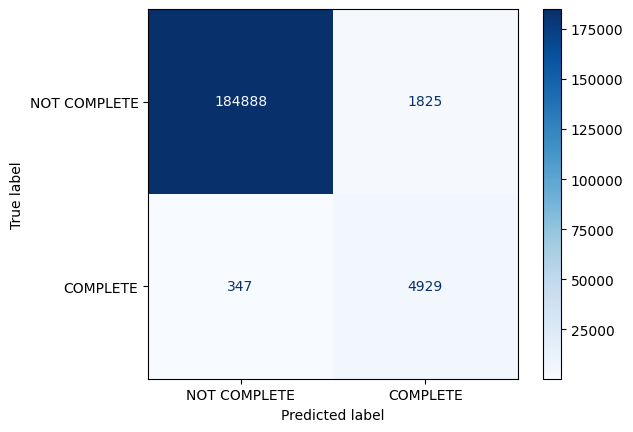

In [10]:
# PLOTTING THE CONFUSION MATRIX FOR THE RESULTS WHEN THRESHOLD = 0.8

cm = confusion_matrix(y_test, y_pred_08)
# Create the display object
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ["NOT COMPLETE", "COMPLETE"])

# Plot the matrix
cm_display.plot(cmap=plt.cm.Blues) # Customize the color map
plt.show()

#### INTERPRETATION OF THE ABOVE CONFUSION MATRIX
##### At a threshold of 0.8, the model correctly identifies 184,888 students who do not complete the course and 4,929 students who successfully complete it.
##### However, the model incorrectly classifies 1,825 students who do not complete the course as WILL COMPLETE (false positives). These students are actually at risk of incompletion, but the model fails to flag them. Additionally, 347 students who actually complete the course are misclassified as NOT COMPLETE (false negatives).
##### Since the goal of this project is to identify students at risk of incompletion early, minimizing the number of false positives (students incorrectly predicted as completers) is critical. At this threshold, 1,825 at-risk students are missed, which leaves room for improvement.

In [11]:
# PREDICTION USING THRESHOLD = 0.9

y_pred_proba_09 = xgb_best_model.predict_proba(X_test)[:, 1]
y_pred_09 = (y_pred_proba_09 >= 0.9).astype(int)

# Evaluation of the above predictions
print("Model performance with threshold = 0.9")
print(f"Accuracy of the final xgboost model is {accuracy_score(y_test, y_pred_09)}.")
print(f"ROC_AUC_SCORE is {roc_auc_score(y_test, y_pred_proba_09)}.")
print("Classification report:")
print()
print(classification_report(y_test, y_pred_09))
print("Confusion matrix:")
print()
print(confusion_matrix(y_test, y_pred_09))

Model performance with threshold = 0.9
Accuracy of the final xgboost model is 0.9902286068472673.
ROC_AUC_SCORE is 0.9972533569428744.
Classification report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    186713
           1       0.78      0.90      0.84      5276

    accuracy                           0.99    191989
   macro avg       0.89      0.95      0.92    191989
weighted avg       0.99      0.99      0.99    191989

Confusion matrix:

[[185347   1366]
 [   510   4766]]


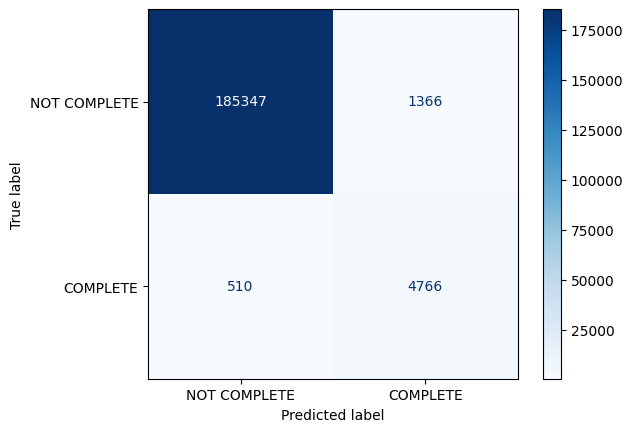

In [12]:
# PLOTTING THE CONFUSION MATRIX FOR THE RESULTS WHEN THRESHOLD = 0.9

cm = confusion_matrix(y_test, y_pred_09)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NOT COMPLETE", "COMPLETE"]
)

cm_display.plot(cmap=plt.cm.Blues)

# SAVE THE PLOT
plt.savefig(
    "../reports/figures/confusion_matrix_final_xgb_model.png",
    bbox_inches="tight",
    dpi=300
)

# THEN show
plt.show()

#### INSIGHTS FROM THE ABOVE CONFUSION MATRIX (THRESHOLD = 0.9)
##### At a threshold of 0.9, the model correctly identifies 185,347 students who are at risk of incompletion, which is an improvement compared to the threshold of 0.8.
##### The number of students incorrectly predicted as WILL COMPLETE (false positives) is reduced from 1,825 to 1,366, meaning that the model now flags more at-risk students correctly. Although this stricter threshold slightly reduces recall for students who complete the course, it aligns better with the project’s objective of identifying potential dropouts.
##### Based on this analysis, XGBoost with a threshold of 0.9 is selected as the final model, as it more effectively identifies students who are at risk of course incompletion and supports timely intervention strategies.

#### To find which type of features the model relies on the most for prediction, we have to find the permutation importances of the features. In this dataset, the features "exploration_rate" and "no_of_courses_explored" are highly correlated with each other, and the features "nevents" and "ndays_act" are highly correlated with each other, so we can use grouped permutation importance to find the feature interpretability.

In [13]:
# Creating a baseline performance as a refernce point.

baseline_pred = xgb_best_model.predict(X_test)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_recall

0.9673995451099318

In [14]:
# Creating feature groups of which we have to find the permutation_importance. Here, we exclude the features which 
# are not so important for prediction, eg: "final_cc_cname_DI", "course_id", etc.

feature_groups = {"Student_activity": ["ndays_act", "nevents"], "Course_exploration": ["no_of_courses_explored"],
                  "Forum_participation": ["nforum_posts"], "Course_structure": ["nchapters"], 
                  "Course_registration": ["no_of_courses_registered"], "Demographics": ["gender", "LoE_DI"]}

In [15]:
# Finding the grouped permutation importance

group_importance = {}

for group_name, features in feature_groups.items():

    # Make a COPY of raw test data
    X_permuted = X_test.copy()

    # Shuffle every feature in the group
    for feature in features:
        X_permuted[feature] = np.random.permutation(X_permuted[feature])

    # Predict again using the SAME pipeline
    permuted_pred = xgb_best_model.predict(X_permuted)

    # Measure recall again
    permuted_recall = recall_score(y_test, permuted_pred)

    # Importance = performance drop
    group_importance[group_name] = baseline_recall - permuted_recall


In [16]:
print(group_importance)

{'Student_activity': 0.83434420015163, 'Course_exploration': 0.02426080363912053, 'Forum_participation': -0.0005686125852919499, 'Course_structure': 0.8936694465504169, 'Course_registration': 0.0, 'Demographics': 0.00018953752843064997}


In [17]:
# Converting the grouped permutation importance results to a dataframe:

importance_df = (
    pd.DataFrame.from_dict(group_importance, orient="index", columns=["Recall Drop"])
    .sort_values(by="Recall Drop", ascending=False)
)

importance_df

,Recall Drop
Course_structure,0.893669
Student_activity,0.834344
Course_exploration,0.024261
Demographics,0.000190
Course_registration,0.000000
Forum_participation,-0.000569


<Figure size 800x500 with 0 Axes>

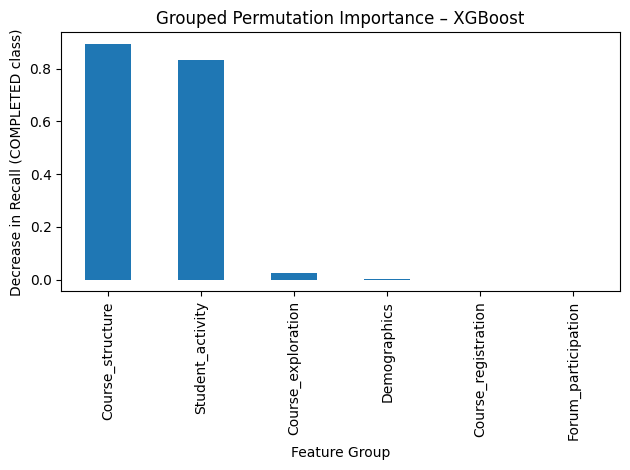

In [18]:
# Plotting the grouped permutation importance:

plt.figure(figsize=(8, 5))

importance_df.plot(kind="bar", legend=False)

plt.ylabel("Decrease in Recall (COMPLETED class)")
plt.xlabel("Feature Group")
plt.title("Grouped Permutation Importance – XGBoost")

plt.tight_layout()

# Save the figure
plt.savefig(
    "../reports/figures/grouped_permutation_importance_xgb.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation from the above graph
##### Grouped permutation importance shows that Course_structure and student activity features have the largest impact on the model’s ability to identify course completion.
##### Course exploration, Course_registration, and Demographic features also contribute meaningfully, while Forum_participation features have relatively limited influence.
##### These results suggest that engagement-driven behaviors are far more predictive of course completion than static student characteristics, which aligns with educational intuition.

In [19]:
# The features like course_id, final_cc_cname_DI, start_time_DI, last_event_DI, YoB are excluded from permutation
# importance because they don't represent meaningful student behavior, and would not add an actionable insight.

#### Model Explainability using SHAP (SHapley Additive exPlanations)
##### While the XGBoost model achieved strong predictive performance, tree-based ensemble models are often considered “black boxes”. To build trust in the model and understand why certain students are predicted to complete or not complete a course, SHAP (SHapley Additive exPlanations) was used.
##### SHAP provides both global explanations (which features matter most overall) and local explanations (why a particular student received a specific prediction), making it well-suited for high-stakes educational decision-making.

In [ ]:
# STEP-BY-STEP CREATION OF SHAP

# EXTRACT PREPROCESSING PIPELINE AND MODEL

# Full trained pipeline
pipe = xgb_best_model

# Preprocessing only (everything except the model)
preprocessor = pipe[:-1]

# Final trained XGBoost model
xgb_model = pipe.named_steps["XGB_final_model"]

In [27]:
# TRANSFORM X_test INTO NUMERIC FEATURE MATRIX

X_test_transformed = preprocessor.transform(X_test)

In [28]:
# DEFINE PREDICTION FUNCTION (ON TRANSFORMED DATA)

def predict_completion_proba_transformed(X):
    return xgb_model.predict_proba(X)[:, 1]

In [29]:
# Select random rows correctly
random_idx = np.random.choice(
    X_test_transformed.shape[0],
    size=100,
    replace=False
)

# CREATE SHAP EXPLAINER
background = X_test_transformed.iloc[random_idx]

explainer = shap.Explainer(
    predict_completion_proba_transformed,
    background
)

In [30]:
shap_values = explainer(X_test_transformed.iloc[:1000])

PermutationExplainer explainer: 1001it [05:14,  3.18it/s]                          


In [31]:
shap_values

.values =
array([[-1.88740371e-03,  1.49413120e-05, -3.18718100e-03, ...,
         1.12681042e-06, -1.48525856e-05,  1.22655324e-05],
       [-1.35879525e-03,  1.22920396e-05, -3.58542049e-03, ...,
         8.93724862e-07,  2.91549034e-05, -4.85352127e-05],
       [ 1.13646614e-03,  7.13958480e-06, -1.26804027e-03, ...,
         3.34483406e-06, -7.14862680e-05, -2.50778985e-05],
       ...,
       [-1.44269419e-03,  5.24154247e-06, -2.54988116e-03, ...,
         5.18005525e-07, -6.22963537e-07, -5.73535205e-06],
       [-5.29218630e-04, -5.21758316e-04, -1.67284512e-03, ...,
         3.57249216e-07, -2.54683365e-05, -1.35212214e-05],
       [-8.01215545e-04, -4.93139667e-04, -2.50652369e-03, ...,
         6.30753495e-07,  7.17401796e-06, -3.49739790e-05]],
      shape=(1000, 28))

.base_values =
array([0.02986421, 0.02986421, 0.02986421, 0.02986421, 0.02986421,
       0.02986421, 0.02986421, 0.02986421, 0.02986421, 0.02986421,
       0.02986421, 0.02986421, 0.02986421, 0.02986421, 0.02

C:\Users\HP\AppData\Local\Temp\ipykernel_22588\3689065275.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


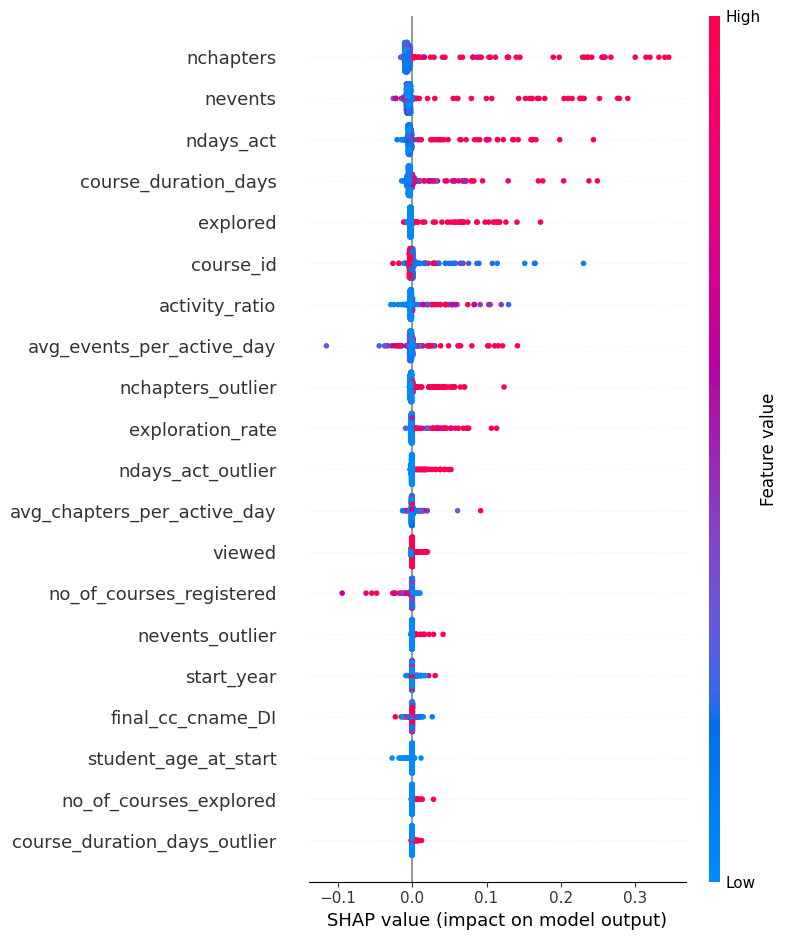

In [32]:
shap.summary_plot(
    shap_values,
    X_test_transformed.iloc[:1000],
    show=False
)

plt.savefig(
    "../reports/figures/shap_summary_xgb.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### INSIGHTS FROM THE ABOVE PLOT
##### The SHAP summary plot shows the overall impact of each feature on the model’s predictions across all students. Features are ranked from top to bottom based on their importance, measured by the average absolute SHAP value.
##### The most influential features in the model are nchapters, nevents, ndays_act, course_duration_days, explored, avg_events_per_active_day, exploration_rate, and activity-related outlier indicators. These features primarily represent student engagement and interaction with the course.
##### For these top features, high feature values (shown in red) generally appear on the positive SHAP value side, indicating that higher engagement (e.g., more chapters accessed, more events, more active days) increases the likelihood of course completion.
##### In contrast, the feature no_of_courses_registered shows red points predominantly on the negative SHAP value side, suggesting that students registered for many courses simultaneously are less likely to complete a given course, possibly due to divided attention or overload.
##### Features such as student_age_at_start, start_year, and final_cc_cname_DI have SHAP values clustered close to zero, indicating that demographic and course identity variables have relatively little influence on the model’s predictions compared to engagement-related metrics.
##### Overall, the SHAP analysis highlights that student engagement behavior is far more important than demographic attributes in predicting course completion.

#### LOCAL EXPLANATION USING SHAP (EXPLANATION FOR A SINGLE STUDENT)

In [33]:
# Picking up the first student (we can pick any random student)

idx = 0

# Compute SHAP for that student
shap_values_single = explainer(X_test_transformed.iloc[[idx]])

PermutationExplainer explainer: 2it [00:11, 11.01s/it]               


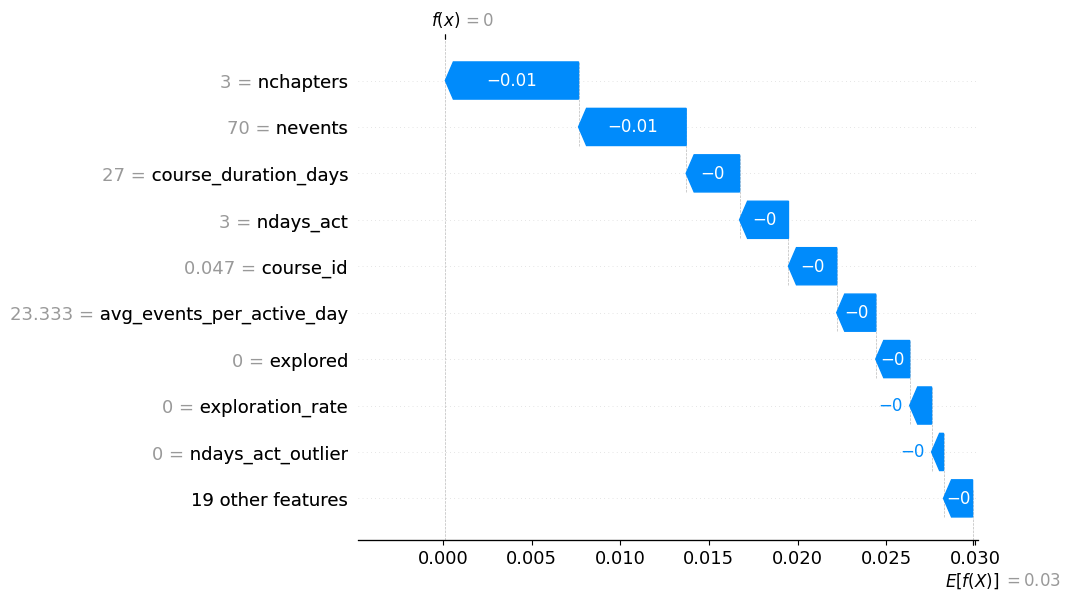

In [34]:
# Creating a SHAP plot for that student

shap.plots.waterfall(shap_values_single[0], show=False)
plt.savefig(
    "../reports/figures/shap_local_explanation_student_0.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

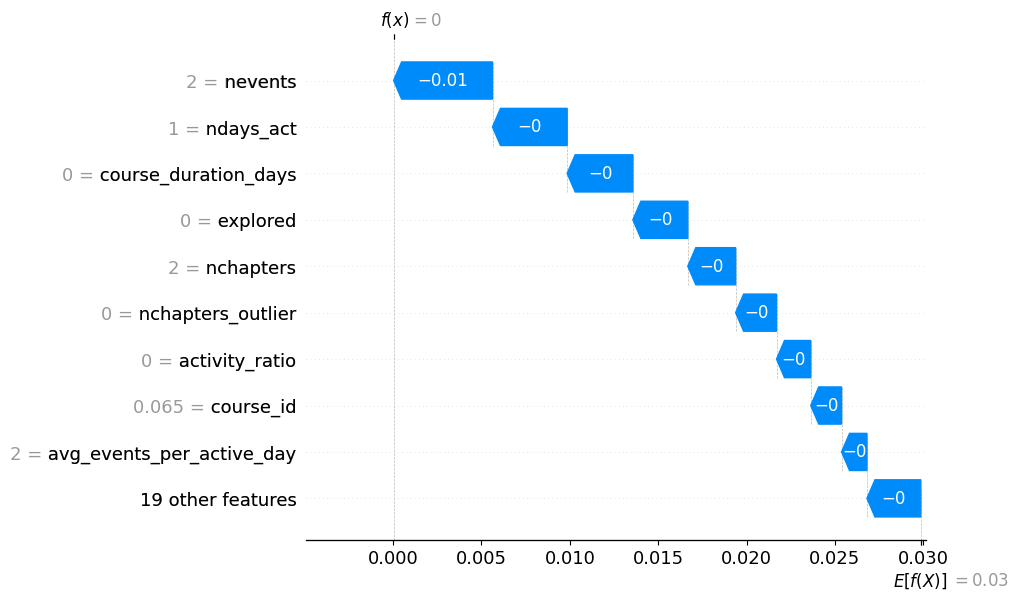

In [37]:
# Creating SHAP explainer for another student:
idx_2 = 500
shap_values_single_2 = explainer(X_test_transformed.iloc[[idx_2]])
# Creating a SHAP plot for that student

shap.plots.waterfall(shap_values_single_2[0], show=False)
plt.savefig(
    "../reports/figures/shap_local_explanation_student_500.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Interpretation from the above plot
##### The value f(x) represents the model’s prediction for this specific student, while E[f(x)] denotes the average prediction across all students in the dataset. In this case, the model predicts “NOT COMPLETE” for this student, as indicated by f(x) = 0.
##### Each bar in the plot shows how an individual feature contributes to this prediction. The blue bars indicate features that push the prediction towards NOT COMPLETE, while the length of each bar represents the strength of that influence.
##### From the plot, we observe that this student has:
##### A very low number of events attended (nevents = 2), activity on only one active day (ndays_act = 1), minimal engagement with course content, including low values for nchapters, activity_ratio, and average events per active day
##### These low engagement levels collectively contribute to shifting the prediction away from course completion. This local explanation clearly shows that lack of sustained engagement is the primary reason the model predicts that this student is unlikely to complete the course.
##### This demonstrates how SHAP can be used to explain individual predictions and identify specific behavioral factors driving a student’s predicted risk of incompletion.

#### BUSINESS RECOMMENDATIONS FROM THE GROUPED PERMUTATIONN IMPORTANCE AND SHAP EXPLAINER:
##### 1. Early Engagement Monitoring: Students with low activity in the initial phase of the course (low events, few active days, minimal chapter exploration) are at high risk of incompletion. Institutions should monitor engagement metrics within the first few days and flag students showing early disengagement.
##### 2. Targeted Interventions: At-risk students can be supported through personalized reminders, nudges, or instructor outreach aimed at increasing early participation and sustained activity.
##### 3. Course Design Improvements: Since features like number of chapters and course duration influence completion, courses can be redesigned to include early interactive content and shorter learning units to encourage consistent engagement.
##### 4. De-emphasizing Demographics: Demographic variables have minimal influence on completion, suggesting that intervention strategies should focus on behavioral signals rather than personal characteristics.

#### LIMITATIONS AND FUTURE WORK
##### The model relies on aggregated engagement metrics (such as total active days, events, and chapters explored) and does not capture the temporal evolution of student behavior. As a result, students who engage later in the course or exhibit changing engagement patterns may be harder to identify accurately. Incorporating time-based or sequential features could improve the model’s ability to capture such dynamics.